In [1]:
import os
import sys
import spacy
import importlib
import config
importlib.reload(config)

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

data_path_kafka = os.path.join(module_path, r"data\kafka_korpus")
data_path_vergleichskorpus = os.path.join(module_path, r"data\Vergleichskorpus\corpus")


def read_txt_file(file_path):
    """
    Read a single txt file and return its content as a string.

    """
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    return text

def read_files_from_folders(folders: list[str]) -> list[dict]:
    from os import listdir
    from os.path import isfile, join

    files = {}
    for folder in folders:

        for f in listdir(folder):
            if isfile(join(folder, f)):
                name = os.path.splitext(f)[0]
                files[name] = os.path.join(folder, f)
        
    return files


# Syntaktische Analyse

Ziel ist es doppelte negationen herauszufinden, meist durch "nicht" gekennzeichnet, z.B. "nicht unsicher"

### Unterscheidung Doppelnegationen:
- Syntaktische Doppelnegation: Zwei separate Negationswörter beziehen sich auf dasselbe Prädikat (z. B. "Ich habe nicht nichts getan").
- Morpho-Syntaktische Doppelnegation: Ein Negationspartikel trifft auf ein Wort mit negierendem Präfix (z. B. "Das ist nicht unüblich")

### Operationalisierung
Eine Doppelnegation liegt vor, wenn **innerhalb desselben Teilsatzes** (d. h. ohne Nebensatzgrenze zu überschreiten) zwei negierende Elemente in einer syntaktischen Abhängigkeitsbeziehung stehen.

**Logik in spaCy:**

1. Iteriere über alle Tokens im Satz.
2. Identifiziere Negationspartikeln (`nicht`, `nie`, …) anhand von POS-Tag (`PART`, `ADV`) und Lemma.
3. Bestimme den **Kopf (head)** der Negation im Dependenzbaum.
4. Durchsuche den **Subtree** dieses Kopfes (nicht nur direkte Kinder), aber **exkludiere untergeordnete Nebensätze** (erkennbar an `dep ∈ {rc, cp, …}` oder subordinierenden Konjunktionen).
5. Prüfe auf **syntaktische Doppelnegation**: Gibt es im selben Subtree ein zweites negierendes Element (z. B. `nichts`, `niemand`, `kein`, weiteres `nicht`)?
6. Prüfe auf **morpho-syntaktische Doppelnegation**: Hat der Kopf der Negation (oder dessen prädikatives Adjektiv/Partizip im Subtree) ein negierendes Präfix (`un-`, `miss-`, …), das nicht in der Ausschlussliste steht?


In [2]:
nlp = spacy.load(config.SPACY_MODEL_DE)

# Daten-Pipeline

Die gesamte Datenproduktion ist in `pipeline.py` ausgelagert. Konfiguration (Werkauswahl, Ausschlüsse) erfolgt über `config.py`.

### Drei DataFrames

**`df_saetze`** — eine Zeile pro Satz (Kern-Tabelle)
| Spalte | Beschreibung |
|---|---|
| `werk_id` | Dateiname ohne .txt |
| `autor` | "Kafka" bzw. aus Dateiname geparst |
| `korpus` | "kafka" / "vergleich" |
| `satz_id` | Laufende Nummer im Werk (0-basiert) |
| `satz` | Satztext |
| `n_tokens` | Anzahl alphabetischer Tokens |
| `n_chars` | Zeichenlänge |
| `satz_position` | Relative Position im Werk (0.0–1.0) |

**`df_morpho`** — eine Zeile pro un-Wort-Vorkommen (Token-Ebene)
| Spalte | Beschreibung |
|---|---|
| `werk_id` | FK → df_saetze |
| `satz_id` | FK → df_saetze |
| `token_text` | Originalform ("unruhig") |
| `lemma` | Lemma ("unruhig") |
| `rest` | Stamm ohne Präfix ("ruhig") |
| `pos_tag` | ADJ / NOUN / ADV / VERB |
| `validierung` | "wordfreq" / "suffix_heuristik" |

**`df_syntax`** — eine Zeile pro Doppelnegation
| Spalte | Beschreibung |
|---|---|
| `werk_id` | FK → df_saetze |
| `satz_id` | FK → df_saetze |
| `typ` | "syntaktisch" / "morpho-syntaktisch" |
| `negation_1` | Erstes Negationselement |
| `negation_2` | Zweites Element (syntaktisch) oder NaN |
| `prefixed_word` | Präfigiertes Wort (morpho-synt.) oder NaN |
| `clause_head` | Kopf des Teilsatzes |
| `dep_relation` | Dep-Label der Negation |

### Metriken (ableitbar aus den DataFrames)
- Doppelnegationen / Gesamtsätze (pro Werk)
- Doppelnegation nach Typ (syntaktisch vs. morpho-syntaktisch)
- un-Wörter / 1000 Tokens
- un-Wörter / Satz
- Negationsdichte (alle Negationswörter / 1000 Tokens)
- Häufigste Negationsformen
- Verteilung über das Werk (via satz_position)

In [3]:
import importlib
import morpho_analyse
import syntax_analyse
import pipeline
importlib.reload(config)
importlib.reload(morpho_analyse)
importlib.reload(syntax_analyse)
importlib.reload(pipeline)

# Pipeline ausführen — beide Korpora
df_saetze, df_morpho, df_syntax = pipeline.run_pipeline(nlp, base_path=module_path, korpus= "beide")

# CSV-Export
output_path = os.path.join(module_path, "output")
os.makedirs(output_path, exist_ok=True)

df_saetze.to_csv(os.path.join(output_path, "df_saetze.csv"), index=False, encoding="utf-8")

df_morpho.to_csv(os.path.join(output_path, "df_morpho.csv"), index=False, encoding="utf-8")
df_syntax.to_csv(os.path.join(output_path, "df_syntax.csv"), index=False, encoding="utf-8")

print(f"\nCSV-Dateien gespeichert in: {output_path}")
print(df_syntax.head(10))

  ⏭ auf_der_galerie übersprungen (~2 Sätze < 20)
  ⏭ das_naechste_dorf übersprungen (~1 Sätze < 20)
  ⏭ das_schweigen_der_sirenen übersprungen (~18 Sätze < 20)
  ⏭ das_stadtwappen übersprungen (~17 Sätze < 20)
  ⏭ der_aufbruch übersprungen (~10 Sätze < 20)
  ⏭ der_geier übersprungen (~8 Sätze < 20)
  ⏭ der_kreisel übersprungen (~7 Sätze < 20)
  ⏭ die_pruefung übersprungen (~19 Sätze < 20)
  ⏭ die_wahrheit_über_sancho_pansa übersprungen (~1 Sätze < 20)
  ⏭ eine_alltägliche_verwirrung übersprungen (~14 Sätze < 20)
  ⏭ eine_kaiserliche_botschaft übersprungen (~9 Sätze < 20)
  ⏭ gemeinschaft übersprungen (~9 Sätze < 20)
  ⏭ gibs_auf übersprungen (~2 Sätze < 20)
  ⏭ grosser_laerm übersprungen (~6 Sätze < 20)
  ⏭ heimkehr übersprungen (~19 Sätze < 20)
  ⏭ kleine_fabel übersprungen (~1 Sätze < 20)
  ⏭ nachts übersprungen (~7 Sätze < 20)
  ⏭ poseidon übersprungen (~11 Sätze < 20)
  ⏭ prometheus übersprungen (~7 Sätze < 20)
  ⏭ vom_scheintod übersprungen (~7 Sätze < 20)
  ⏭ von_den_gleichnissen

In [4]:
# Schnellübersicht
print(f"=== df_saetze: {len(df_saetze)} Zeilen ===")
print(df_saetze.groupby("korpus")[["n_tokens"]].agg(["count", "sum"]))

print(f"\n=== df_morpho: {len(df_morpho)} negierte Affixe ===")
if "affix" in df_morpho.columns:
    print(df_morpho.groupby(["affix_typ", "affix"]).size().reset_index(name="count").sort_values("count", ascending=False))
print()
print(df_morpho.head(10))

print(f"\n=== df_syntax: {len(df_syntax)} Doppelnegationen ===")
print(df_syntax.head(10))

=== df_saetze: 129079 Zeilen ===
          n_tokens         
             count      sum
korpus                     
kafka        19580   379512
vergleich   109499  1466079

=== df_morpho: 11051 negierte Affixe ===
  affix_typ  affix  count
4    präfix     un   8665
6    suffix    los   2218
3    präfix  nicht    101
5    suffix   frei     41
1    präfix     ir     17
0    präfix     il      5
2    präfix   miss      4

   werk_id  satz_id          token_text               lemma affix_typ  affix  \
0  amerika       20         unversehens         unversehens    präfix     un   
1  amerika       22         unbehaglich         unbehaglich    präfix     un   
2  amerika       62  Nichteingestandene  nichteingestandene    präfix  nicht   
3  amerika       76      unvergleichbar      unvergleichbar    präfix     un   
4  amerika      100          unsicheren            unsicher    präfix     un   
5  amerika      100         unbekannten           unbekannt    präfix     un   
6  amerika      

In [5]:
# Inspektion: Neue Affixe auf False Positives prüfen
# Lateinische Präfixe + Suffixe separat anzeigen

neue_affixe = df_morpho[df_morpho["affix"].isin(["in", "il", "ir", "a", "an", "non", "des", "dis", "los", "frei"])]
print(f"Funde mit neuen Affixen: {len(neue_affixe)}")
print()

for affix, group in neue_affixe.groupby("affix"):
    unique = group[["lemma", "rest", "affix_typ"]].drop_duplicates().sort_values("lemma")
    print(f"── {affix} ({len(group)} Vorkommen, {len(unique)} Types) ──")
    for _, row in unique.iterrows():
        print(f"  {row['lemma']:25s} → {row['rest']:20s} ({row['affix_typ']})")
    print()

Funde mit neuen Affixen: 2281

── frei (41 Vorkommen, 17 Types) ──
  alkoholfrei               → alkohol              (suffix)
  altfrei                   → alt                  (suffix)
  baumfrei                  → baum                 (suffix)
  dienstfrei                → dienst               (suffix)
  einwandfrei               → einwand              (suffix)
  fehlerfrei                → fehler               (suffix)
  fieberfrei                → fieber               (suffix)
  fußfrei                   → fuß                  (suffix)
  honorarfrei               → honorar              (suffix)
  kostenfrei                → koste                (suffix)
  moralfrei                 → moral                (suffix)
  schuldenfrei              → schulde              (suffix)
  schulfrei                 → schul                (suffix)
  sorgenfrei                → sorge                (suffix)
  staubfrei                 → staub                (suffix)
  vorwurfsfrei              → vor

# Statistische Analyse — Mann-Whitney-U-Test

**H₀**: Kafka benutzt nicht signifikant mehr Negierungen als die anderen Autoren im Datensatz.  
**H₁**: Kafka benutzt signifikant mehr Negierungen (einseitig).

Beobachtungseinheit = **Werk**. Pro Werk wird eine Rate berechnet, dann Gruppe Kafka vs. Vergleich verglichen.

Getestet werden drei Metriken:
1. **Morphologische Negationen / 1000 Tokens** (un-, miss-, -los, -frei, ...)
2. **Doppelnegationen / 100 Sätze**
3. **Anteil Sätze mit mindestens einer morphologischen Negation (%)**

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# ── 1. Daten aus Output laden ──────────────────────────────────
df_saetze = pd.read_csv(os.path.join(module_path, "output", "df_saetze.csv"))
df_morpho = pd.read_csv(os.path.join(module_path, "output", "df_morpho.csv"))
df_syntax = pd.read_csv(os.path.join(module_path, "output", "df_syntax.csv"))

# ── 2. Werk-Level Statistiken berechnen ────────────────────────
werk_stats = df_saetze.groupby(["werk_id", "korpus", "autor"]).agg(
    n_saetze=("satz_id", "count"),
    n_tokens=("n_tokens", "sum"),
).reset_index()

# Morphologische Negationen pro Werk
morpho_counts = df_morpho.groupby("werk_id").size().rename("n_morpho_neg")
werk_stats = werk_stats.merge(morpho_counts, on="werk_id", how="left")
werk_stats["n_morpho_neg"] = werk_stats["n_morpho_neg"].fillna(0).astype(int)

# Sätze mit mind. einer morphologischen Negation
saetze_mit_neg = df_morpho.groupby("werk_id")["satz_id"].nunique().rename("n_saetze_mit_neg")
werk_stats = werk_stats.merge(saetze_mit_neg, on="werk_id", how="left")
werk_stats["n_saetze_mit_neg"] = werk_stats["n_saetze_mit_neg"].fillna(0).astype(int)

# Doppelnegationen pro Werk
dn_counts = df_syntax.groupby("werk_id").size().rename("n_doppelneg")
werk_stats = werk_stats.merge(dn_counts, on="werk_id", how="left")
werk_stats["n_doppelneg"] = werk_stats["n_doppelneg"].fillna(0).astype(int)

# ── 3. Raten berechnen ─────────────────────────────────────────
werk_stats["morpho_per_1000"] = werk_stats["n_morpho_neg"] / werk_stats["n_tokens"] * 1000
werk_stats["dn_in_percent"] = werk_stats["n_doppelneg"] / werk_stats["n_saetze"] *100
werk_stats["pct_saetze_mit_neg"] = werk_stats["n_saetze_mit_neg"] / werk_stats["n_saetze"] * 100

print(f"Werke gesamt: {len(werk_stats)}")
print(f"  Kafka:     {len(werk_stats[werk_stats['korpus'] == 'kafka'])}")
print(f"  Vergleich: {len(werk_stats[werk_stats['korpus'] == 'vergleich'])}")
print()
print(werk_stats[["werk_id", "korpus", "n_saetze", "n_tokens", "morpho_per_1000", "dn_in_percent", "pct_saetze_mit_neg"]].to_string(index=False))

Werke gesamt: 74
  Kafka:     41
  Vergleich: 33

                              werk_id    korpus  n_saetze  n_tokens  morpho_per_1000  dn_in_percent  pct_saetze_mit_neg
            Beer-Hofmann_DerTodGeorgs vergleich      2165     36798        10.571227       1.293303           15.658199
                         Benn_Gehirne vergleich       966     12444         5.464481       0.724638            6.314700
   Brod_ArnoldBeerSchicksalEinesJuden vergleich      2350     44309         7.876504       2.127660           12.170213
                  Ehrenstein_Tubutsch vergleich       626      8874         8.000902       0.958466           10.063898
             Ehrenstein_Zaubermärchen vergleich       583     10949         7.032606       1.543739           10.977702
                    HMann_DerUntertan vergleich     10723    129762         4.485134       0.587522            5.213093
                 HMann_ProfessorUnrat vergleich      4759     59167         5.712644       0.504308           

In [7]:
# ── 4. Mann-Whitney-U-Test ──────────────────────────────────────
# H₀: Kafka benutzt nicht signifikant mehr Negierungen
# H₁: Kafka benutzt mehr (einseitig → alternative="greater")

kafka = werk_stats[werk_stats["korpus"] == "kafka"]
vergleich = werk_stats[werk_stats["korpus"] == "vergleich"]

metriken = {
    "Morpho. Negationen / 1000 Tokens": "morpho_per_1000",
    "Doppelnegationen":     "dn_in_percent",
    "% Sätze mit Negation":             "pct_saetze_mit_neg",
}

results = []

for label, col in metriken.items():
    kafka_vals = kafka[col].values
    vergl_vals = vergleich[col].values
    
    # Mann-Whitney U (einseitig: Kafka > Vergleich)
    U, p = mannwhitneyu(kafka_vals, vergl_vals, alternative="greater")
    
    # Effektstärke: rank-biserial correlation
    n1, n2 = len(kafka_vals), len(vergl_vals)
    r_rb = (2 * U) / (n1 * n2) - 1
    
    results.append({
        "Metrik": label,
        "Kafka Median": f"{np.median(kafka_vals):.2f}",
        "Kafka Mean":   f"{np.mean(kafka_vals):.2f}",
        "Vergl. Median": f"{np.median(vergl_vals):.2f}",
        "Vergl. Mean":   f"{np.mean(vergl_vals):.2f}",
        "U-Statistik": f"{U:.0f}",
        "p-Wert":      f"{p:.4f}",
        "Effektstärke r": f"{r_rb:.3f}",
        "Signifikant (α=0.05)": "✅ Ja" if p < 0.05 else "❌ Nein",
    })

df_results = pd.DataFrame(results)
print("=" * 80)
print("Mann-Whitney-U-Test: Kafka vs. Vergleichskorpus (einseitig, H₁: Kafka > Vergl.)")
print("=" * 80)
print()
print(df_results.to_string(index=False))
print()
print("Interpretation Effektstärke r (rank-biserial):")
print("  |r| < 0.1: vernachlässigbar")
print("  |r| 0.1–0.3: klein")
print("  |r| 0.3–0.5: mittel")
print("  |r| > 0.5: groß")

Mann-Whitney-U-Test: Kafka vs. Vergleichskorpus (einseitig, H₁: Kafka > Vergl.)

                          Metrik Kafka Median Kafka Mean Vergl. Median Vergl. Mean U-Statistik p-Wert Effektstärke r Signifikant (α=0.05)
Morpho. Negationen / 1000 Tokens         7.07       7.49          6.00        5.78         892 0.0097          0.319                 ✅ Ja
                Doppelnegationen         1.97       2.96          0.96        1.18         897 0.0083          0.326                 ✅ Ja
            % Sätze mit Negation        11.09      12.08          6.31        7.50        1008 0.0002          0.490                 ✅ Ja

Interpretation Effektstärke r (rank-biserial):
  |r| < 0.1: vernachlässigbar
  |r| 0.1–0.3: klein
  |r| 0.3–0.5: mittel
  |r| > 0.5: groß


C:\Users\BenMangel\AppData\Local\Temp\ipykernel_15280\864974469.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\BenMangel\AppData\Local\Temp\ipykernel_15280\864974469.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\BenMangel\AppData\Local\Temp\ipykernel_15280\864974469.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


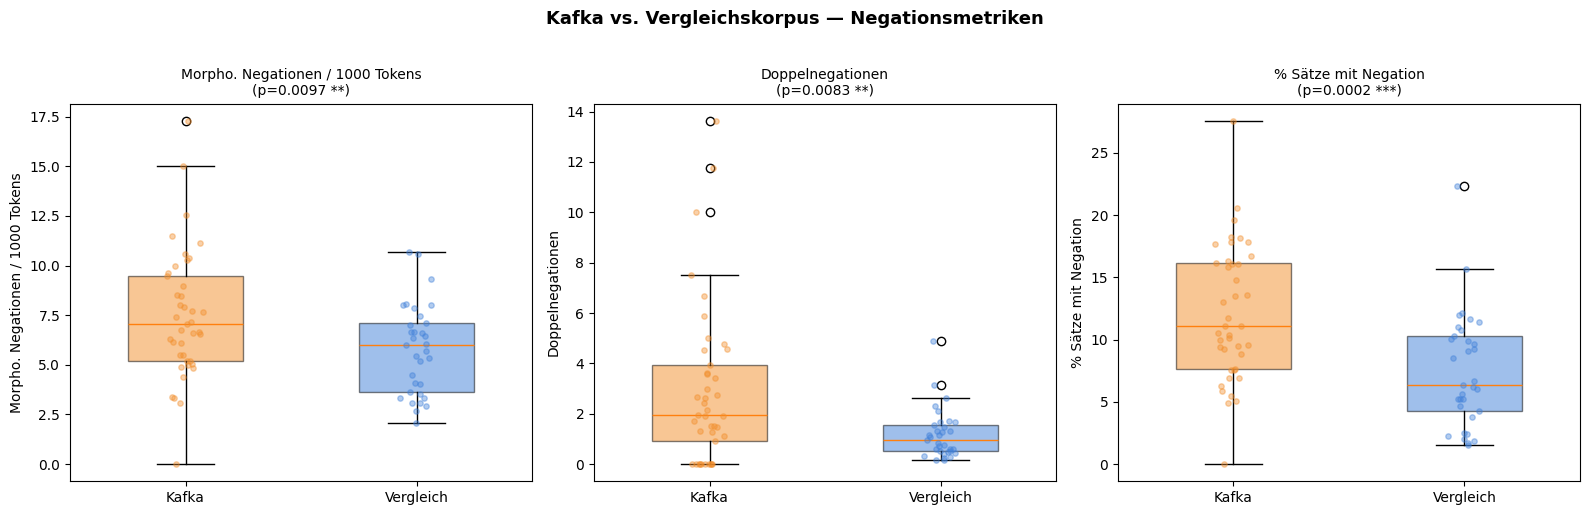

Plot gespeichert: output/mann_whitney_boxplots.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, col) in zip(axes, metriken.items()):
    kafka_vals = kafka[col].values
    vergl_vals = vergleich[col].values
    
    # Boxplot
    bp = ax.boxplot(
        [kafka_vals, vergl_vals],
        labels=["Kafka", "Vergleich"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor("#f28e2b")
    bp["boxes"][0].set_alpha(0.5)
    bp["boxes"][1].set_facecolor("#4080d9")
    bp["boxes"][1].set_alpha(0.5)
    
    # Einzelwerte als Punkte
    np.random.seed(42)
    jitter_k = np.random.normal(1, 0.04, size=len(kafka_vals))
    jitter_v = np.random.normal(2, 0.04, size=len(vergl_vals))
    ax.scatter(jitter_k, kafka_vals, alpha=0.4, color="#f28e2b", s=15, zorder=3)
    ax.scatter(jitter_v, vergl_vals, alpha=0.4, color="#4080d9", s=15, zorder=3)
    
    # p-Wert annotation
    U, p = mannwhitneyu(kafka_vals, vergl_vals, alternative="greater")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    ax.set_title(f"{label}\n(p={p:.4f} {sig})", fontsize=10)
    ax.set_ylabel(label)

plt.suptitle("Kafka vs. Vergleichskorpus — Negationsmetriken", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(module_path, "output", "mann_whitney_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: output/mann_whitney_boxplots.png")

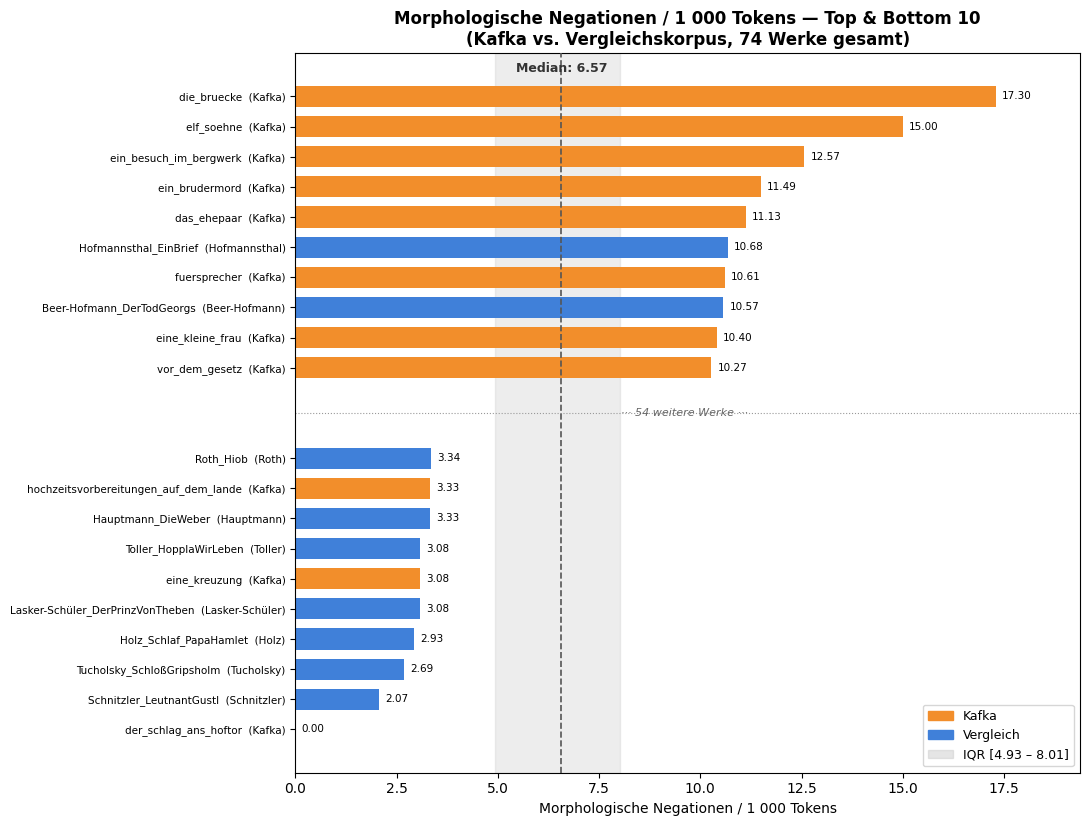

Plot gespeichert: output/morpho_neg_barplot.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Parameter ────────────────────────────────────────────────────
N = 10                       # Top-N und Bottom-N anzeigen
col = "morpho_per_1000"

# ── Daten vorbereiten ────────────────────────────────────────────
full_df = werk_stats[["werk_id", "autor", "korpus", col]].copy()
full_df = full_df.sort_values(col, ascending=False).reset_index(drop=True)

top_n    = full_df.head(N).copy()
bottom_n = full_df.tail(N).copy()

# Median & IQR über ALLE Werke
median_val = full_df[col].median()
q1 = full_df[col].quantile(0.25)
q3 = full_df[col].quantile(0.75)

# Zusammenfügen mit Trennzeile
top_n["_pos"] = range(N)                        # 0 .. 14
bottom_n["_pos"] = range(N + 2, 2 * N + 2)      # 16 .. 30  (Lücke bei 15)
plot_df = pd.concat([top_n, bottom_n], ignore_index=True)

n_hidden = len(full_df) - 2 * N

# Farben
farbe_kafka = "#f28e2b"
farbe_vergl = "#4080d9"
bar_colors = [farbe_kafka if k == "kafka" else farbe_vergl for k in plot_df["korpus"]]

# ── Plot ─────────────────────────────────────────────────────────
fig_height = (2 * N + 2) * 0.38
fig, ax = plt.subplots(figsize=(11, fig_height))

bars = ax.barh(plot_df["_pos"], plot_df[col], color=bar_colors,
               edgecolor="none", height=0.7)

# Werte neben Balken
for _, row in plot_df.iterrows():
    ax.text(row[col] + 0.15, row["_pos"], f"{row[col]:.2f}",
            va="center", fontsize=7.5)

# Y-Achse
ax.set_yticks(plot_df["_pos"])
ax.set_yticklabels(
    [f"{r.werk_id}  ({r.autor})" for _, r in plot_df.iterrows()],
    fontsize=7.5,
)
ax.invert_yaxis()

# ── Trennlinie (»…«) ────────────────────────────────────────────
gap_y = N + 0.5
ax.axhline(gap_y, color="#999999", linewidth=0.8, linestyle=":")
ax.text(full_df[col].max() * 0.55, gap_y,
        f"  ··· {n_hidden} weitere Werke ···",
        va="center", ha="center", fontsize=8, color="#666666",
        fontstyle="italic")

# ── Median-Linie + IQR-Band ─────────────────────────────────────
ax.axvline(median_val, color="#555555", linewidth=1.2, linestyle="--", zorder=3)
ax.axvspan(q1, q3, color="#cccccc", alpha=0.35, zorder=0)
ax.text(median_val, -0.8, f"Median: {median_val:.2f}",
        ha="center", fontsize=9, color="#333333", fontweight="bold")

# ── Legende ──────────────────────────────────────────────────────
kafka_patch = mpatches.Patch(color=farbe_kafka, label="Kafka")
vergl_patch = mpatches.Patch(color=farbe_vergl, label="Vergleich")
iqr_patch   = mpatches.Patch(color="#cccccc", alpha=0.5,
                              label=f"IQR [{q1:.2f} – {q3:.2f}]")
ax.legend(handles=[kafka_patch, vergl_patch, iqr_patch],
          loc="lower right", fontsize=9)

ax.set_xlabel("Morphologische Negationen / 1 000 Tokens", fontsize=10)
ax.set_title(f"Morphologische Negationen / 1 000 Tokens — Top & Bottom {N}\n"
             f"(Kafka vs. Vergleichskorpus, {len(full_df)} Werke gesamt)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, full_df[col].max() * 1.12)

plt.tight_layout()
plt.savefig(os.path.join(module_path, "output", "morpho_neg_barplot.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: output/morpho_neg_barplot.png")

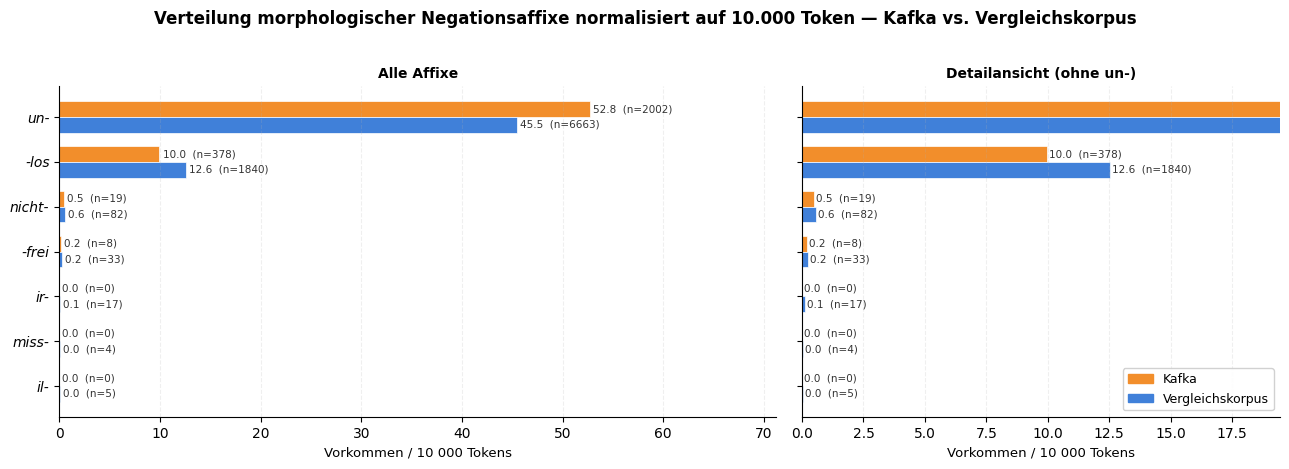

Plot gespeichert: output/affix_verteilung.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Affix-Counts pro Korpus berechnen ────────────────────────────
affix_df = df_morpho.merge(
    df_saetze[["werk_id", "satz_id", "korpus"]].drop_duplicates(),
    on=["werk_id", "satz_id"], how="left"
)
counts = affix_df.groupby(["affix", "korpus"]).size().unstack(fill_value=0)

# Token-Summen pro Korpus
tokens_pro_korpus = df_saetze.groupby("korpus")["n_tokens"].sum()

# Normalisiert: pro 10 000 Tokens
norm = (counts.div(tokens_pro_korpus, axis=1) * 10_000).round(2)
norm["_total"] = norm.sum(axis=1)
norm = norm.sort_values("_total", ascending=True)
counts = counts.loc[norm.index]
norm = norm.drop(columns="_total")

# Affix-Labels
affix_typ_map = affix_df.groupby("affix")["affix_typ"].first()
label_map = {
    a: f"{a}-" if affix_typ_map.get(a) == "präfix" else f"-{a}"
    for a in norm.index
}

# ── Farben & Layout ──────────────────────────────────────────────
farbe_kafka = "#f28e2b"
farbe_vergl = "#4080d9"
bar_h = 0.35

fig, (ax_main, ax_zoom) = plt.subplots(
    1, 2, figsize=(13, max(3.5, len(norm) * 0.65)),
    gridspec_kw={"width_ratios": [3, 2]}, sharey=True
)

y = np.arange(len(norm))

# ── Hauptplot (alle Affixe, volle Skala) ─────────────────────────
for ax in [ax_main, ax_zoom]:
    bars_k = ax.barh(y + bar_h/2, norm["kafka"], height=bar_h,
                      color=farbe_kafka, edgecolor="white", linewidth=0.5)
    bars_v = ax.barh(y - bar_h/2, norm["vergleich"], height=bar_h,
                      color=farbe_vergl, edgecolor="white", linewidth=0.5)

# Annotationen Hauptplot
for i, affix in enumerate(norm.index):
    for korpus, offset in [("kafka", bar_h/2), ("vergleich", -bar_h/2)]:
        val = norm.loc[affix, korpus]
        n_abs = int(counts.loc[affix, korpus])
        ax_main.text(val + 0.3, i + offset, f"{val:.1f}  (n={n_abs})",
                     va="center", fontsize=7.5, color="#333333")

ax_main.set_yticks(y)
ax_main.set_yticklabels([label_map[a] for a in norm.index], fontsize=10, fontstyle="italic")
ax_main.set_xlabel("Vorkommen / 10 000 Tokens", fontsize=9.5)
ax_main.set_title("Alle Affixe", fontsize=10, fontweight="bold")
ax_main.set_xlim(0, norm.values.max() * 1.35)
ax_main.spines["top"].set_visible(False)
ax_main.spines["right"].set_visible(False)
ax_main.grid(axis="x", alpha=0.2, linestyle="--")

# ── Zoom-Panel (ohne un-, Detailansicht) ─────────────────────────
zoom_max = norm.drop("un", errors="ignore").values.max()
for i, affix in enumerate(norm.index):
    for korpus, offset in [("kafka", bar_h/2), ("vergleich", -bar_h/2)]:
        val = norm.loc[affix, korpus]
        n_abs = int(counts.loc[affix, korpus])
        if val <= zoom_max * 1.1:
            ax_zoom.text(val + 0.08, i + offset, f"{val:.1f}  (n={n_abs})",
                         va="center", fontsize=7.5, color="#333333")

ax_zoom.set_xlim(0, zoom_max * 1.55)
ax_zoom.set_xlabel("Vorkommen / 10 000 Tokens", fontsize=9.5)
ax_zoom.set_title("Detailansicht (ohne un-)", fontsize=10, fontweight="bold")
ax_zoom.spines["top"].set_visible(False)
ax_zoom.spines["right"].set_visible(False)
ax_zoom.grid(axis="x", alpha=0.2, linestyle="--")

# Legende
kafka_p = mpatches.Patch(color=farbe_kafka, label="Kafka")
vergl_p = mpatches.Patch(color=farbe_vergl, label="Vergleichskorpus")
ax_zoom.legend(handles=[kafka_p, vergl_p], loc="lower right", fontsize=9, framealpha=0.9)

fig.suptitle("Verteilung morphologischer Negationsaffixe normalisiert auf 10.000 Token — Kafka vs. Vergleichskorpus",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(module_path, "output", "affix_verteilung.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: output/affix_verteilung.png")

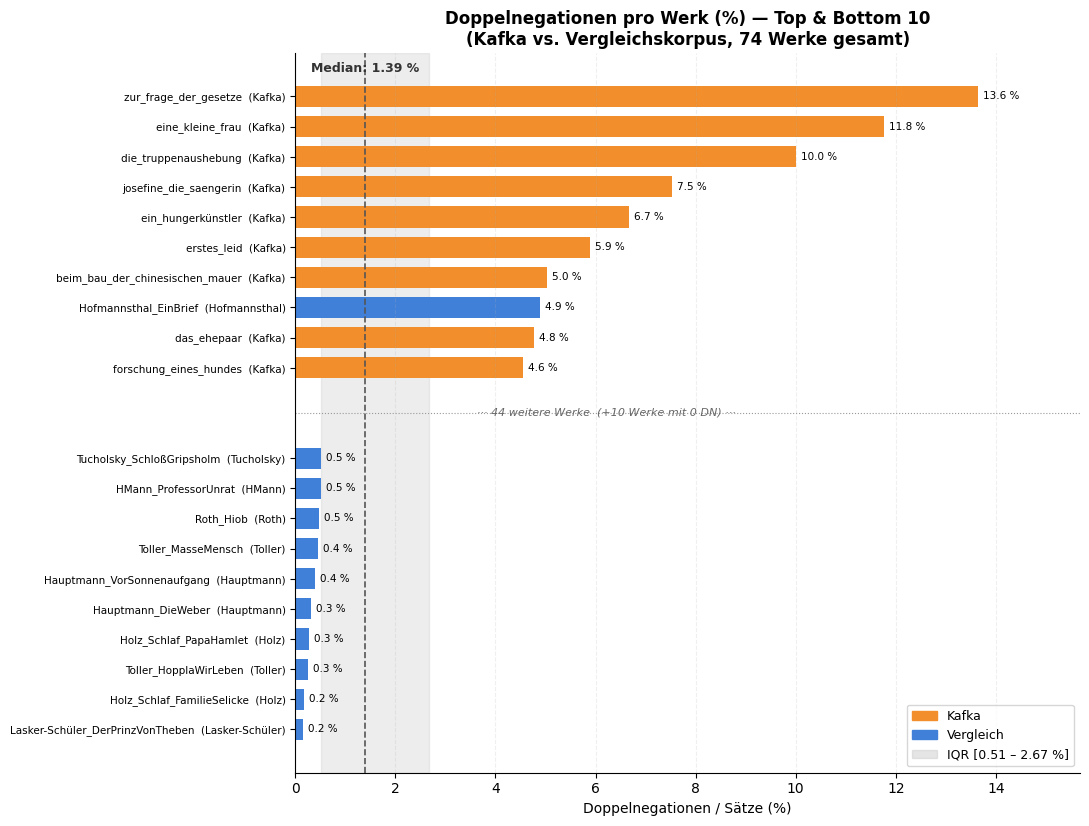

Plot gespeichert: output/doppelneg_barplot.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Parameter ────────────────────────────────────────────────────
N = 10
col = "dn_in_percent"

# ── Daten: nur Werke mit mind. 1 Doppelnegation ─────────────────
full_df = werk_stats[["werk_id", "autor", "korpus", col]].copy()
full_df = full_df[full_df[col] > 0]  # Werke ohne DN ausblenden
full_df = full_df.sort_values(col, ascending=False).reset_index(drop=True)

# Werte sind bereits in % (dn_in_percent = n_doppelneg / n_saetze * 100)
full_df["dn_pct"] = full_df[col]

top_n    = full_df.head(N).copy()
bottom_n = full_df.tail(N).copy()

# Median & IQR über ALLE Werke (inkl. 0er) — bereits in %
all_vals = werk_stats[col]
median_val = all_vals.median()
q1 = all_vals.quantile(0.25)
q3 = all_vals.quantile(0.75)

# Positionen mit Lücke
top_n["_pos"] = range(N)
bottom_n["_pos"] = range(N + 2, 2 * N + 2)
plot_df = pd.concat([top_n, bottom_n], ignore_index=True)
n_hidden = len(full_df) - 2 * N
n_zero = len(werk_stats) - len(full_df)

# Farben
farbe_kafka = "#f28e2b"
farbe_vergl = "#4080d9"
bar_colors = [farbe_kafka if k == "kafka" else farbe_vergl for k in plot_df["korpus"]]

# ── Plot ─────────────────────────────────────────────────────────
fig_height = (2 * N + 2) * 0.38
fig, ax = plt.subplots(figsize=(11, fig_height))

bars = ax.barh(plot_df["_pos"], plot_df["dn_pct"], color=bar_colors,
               edgecolor="none", height=0.7)

# Werte neben Balken
for _, row in plot_df.iterrows():
    ax.text(row["dn_pct"] + 0.1, row["_pos"],
            f"{row['dn_pct']:.1f} %",
            va="center", fontsize=7.5)

# Y-Achse
ax.set_yticks(plot_df["_pos"])
ax.set_yticklabels(
    [f"{r.werk_id}  ({r.autor})" for _, r in plot_df.iterrows()],
    fontsize=7.5,
)
ax.invert_yaxis()

# ── Trennlinie ──────────────────────────────────────────────────
gap_y = N + 0.5
ax.axhline(gap_y, color="#999999", linewidth=0.8, linestyle=":")
ax.text(plot_df["dn_pct"].max() * 0.45, gap_y,
        f"  ··· {n_hidden} weitere Werke  (+{n_zero} Werke mit 0 DN) ···",
        va="center", ha="center", fontsize=8, color="#666666",
        fontstyle="italic")

# ── Median-Linie + IQR-Band ─────────────────────────────────────
ax.axvline(median_val, color="#555555", linewidth=1.2, linestyle="--", zorder=3)
ax.axvspan(q1, q3, color="#cccccc", alpha=0.35, zorder=0)
ax.text(median_val, -0.8, f"Median: {median_val:.2f} %",
        ha="center", fontsize=9, color="#333333", fontweight="bold")

# ── Legende ──────────────────────────────────────────────────────
kafka_patch = mpatches.Patch(color=farbe_kafka, label="Kafka")
vergl_patch = mpatches.Patch(color=farbe_vergl, label="Vergleich")
iqr_patch   = mpatches.Patch(color="#cccccc", alpha=0.5,
                              label=f"IQR [{q1:.2f} – {q3:.2f} %]")
ax.legend(handles=[kafka_patch, vergl_patch, iqr_patch],
          loc="lower right", fontsize=9)

ax.set_xlabel("Doppelnegationen / Sätze (%)", fontsize=10)
ax.set_title(f"Doppelnegationen pro Werk (%) — Top & Bottom {N}\n"
             f"(Kafka vs. Vergleichskorpus, {len(werk_stats)} Werke gesamt)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, plot_df["dn_pct"].max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig(os.path.join(module_path, "output", "doppelneg_barplot.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: output/doppelneg_barplot.png")

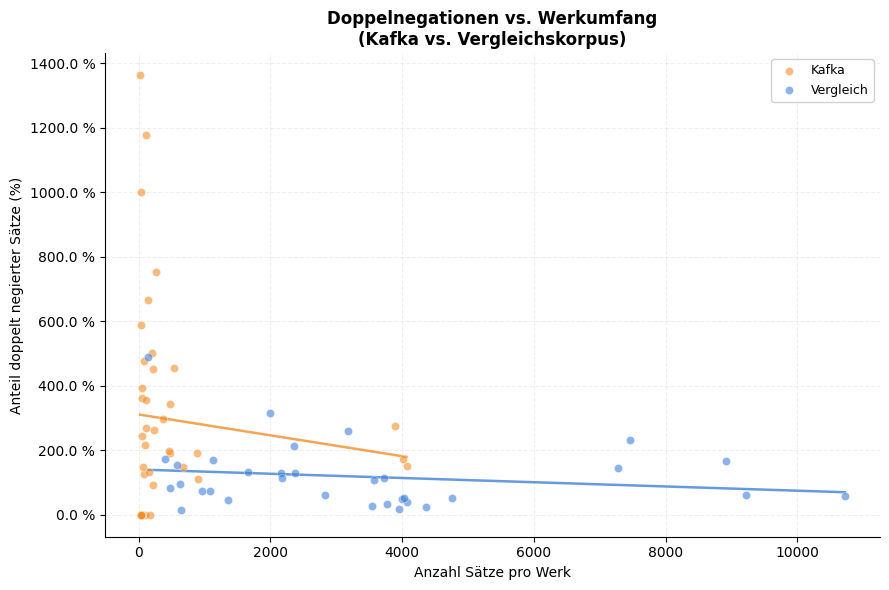

Plot gespeichert: output/doppelneg_vs_saetze_scatter.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

farbe_kafka = "#f28e2b"
farbe_vergl = "#4080d9"

fig, ax = plt.subplots(figsize=(9, 6))

for korpus, color, label in [("kafka", farbe_kafka, "Kafka"),
                              ("vergleich", farbe_vergl, "Vergleich")]:
    sub = werk_stats[werk_stats["korpus"] == korpus]
    x = sub["n_saetze"].values
    y = sub["dn_in_percent"].values * 100  # in Prozent

    # Scatterplot
    ax.scatter(x, y, color=color, alpha=0.6, s=35, edgecolors="white",
               linewidth=0.4, label=label, zorder=3)

    # Regressionsgerade
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() > 1:
        coef = np.polyfit(x[mask], y[mask], 1)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, np.polyval(coef, x_line), color=color,
                linewidth=1.8, alpha=0.8, zorder=2)

# Achsen & Titel
ax.set_xlabel("Anzahl Sätze pro Werk", fontsize=10)
ax.set_ylabel("Anteil doppelt negierter Sätze (%)", fontsize=10)
ax.set_title("Doppelnegationen vs. Werkumfang\n(Kafka vs. Vergleichskorpus)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f} %"))

ax.legend(fontsize=9, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig(os.path.join(module_path, "output", "doppelneg_vs_saetze_scatter.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: output/doppelneg_vs_saetze_scatter.png")

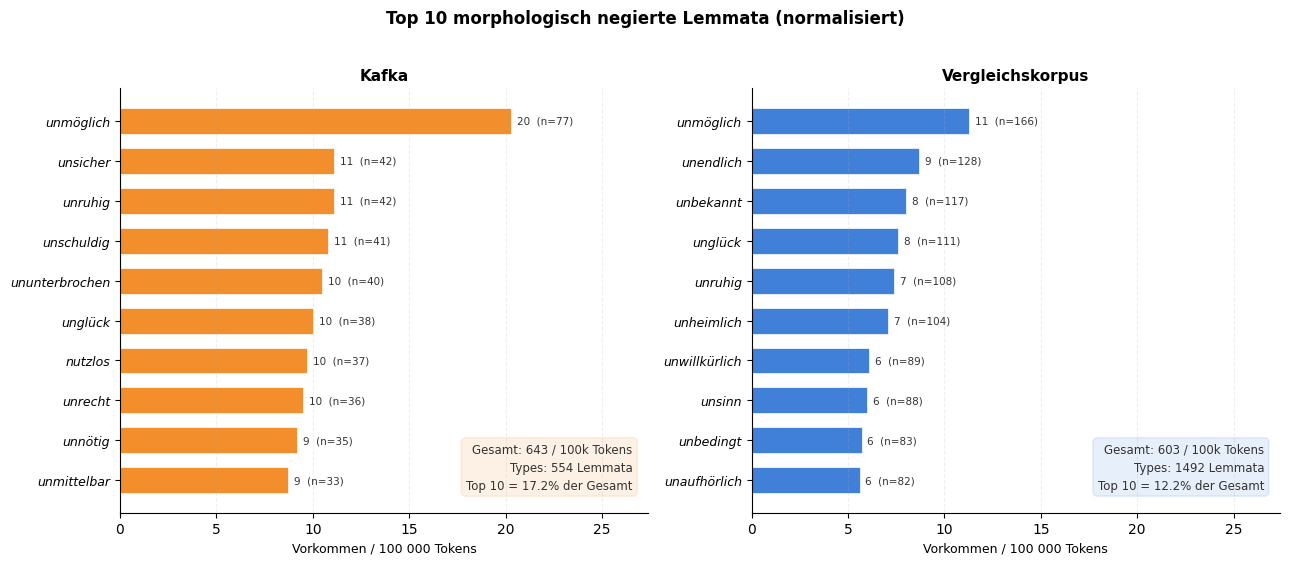

Plot gespeichert: output/top_lemma_side_by_side.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

N_TOP = 10
farbe_kafka = "#f28e2b"
farbe_vergl = "#4080d9"

# ── Korpus-Zuordnung + Token-Normalisierung ──────────────────────
lemma_df = df_morpho.merge(
    df_saetze[["werk_id", "satz_id", "korpus"]].drop_duplicates(),
    on=["werk_id", "satz_id"], how="left"
)
tokens_pro_korpus = df_saetze.groupby("korpus")["n_tokens"].sum()

# Counts pro Lemma × Korpus
lemma_counts = lemma_df.groupby(["lemma", "korpus"]).size().unstack(fill_value=0)
# Normalisiert: pro 100 000 Tokens (lesbarer bei einzelnen Lemmata)
lemma_norm = (lemma_counts.div(tokens_pro_korpus, axis=1) * 100_000).round(1)

# Total negierte Lemmata / 100 000 Tokens pro Korpus
total_norm = lemma_norm.sum()
# Anzahl einzigartiger Lemmata (Types) pro Korpus
n_types = (lemma_counts > 0).sum()

# Top 10 je Gruppe
top_kafka  = lemma_norm["kafka"].nlargest(N_TOP)
top_vergl  = lemma_norm["vergleich"].nlargest(N_TOP)

# ── Gemeinsame Achse berechnen ───────────────────────────────────
shared_max = max(top_kafka.max(), top_vergl.max()) * 1.35

# ── Side-by-side Top 10 ─────────────────────────────────────────
fig, (ax_k, ax_v) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)

for ax, top, color, titel, korpus in [
    (ax_k, top_kafka,  farbe_kafka, "Kafka",          "kafka"),
    (ax_v, top_vergl,  farbe_vergl, "Vergleichskorpus", "vergleich"),
]:
    top_sorted = top.sort_values(ascending=True)
    y = np.arange(len(top_sorted))
    ax.barh(y, top_sorted.values, color=color, edgecolor="white",
            linewidth=0.5, height=0.65)
    ax.set_yticks(y)
    ax.set_yticklabels(top_sorted.index, fontsize=9, fontstyle="italic")
    ax.set_xlabel("Vorkommen / 100 000 Tokens", fontsize=9)
    ax.set_title(titel, fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.2, linestyle="--")

    # Annotationen: normalisiert + (absolut)
    for i, lemma in enumerate(top_sorted.index):
        val = top_sorted[lemma]
        n_abs = int(lemma_counts.loc[lemma, korpus])
        ax.text(val + 0.3, i, f"{val:.0f}  (n={n_abs})",
                va="center", fontsize=7.5, color="#333333")
    ax.set_xlim(0, shared_max)

    # ── Infobox: Total + Anteil Top 10 ───────────────────────────
    total_val = total_norm[korpus]
    top_sum = top_sorted.sum()
    pct_of_total = top_sum / total_val * 100
    types = int(n_types[korpus])
    info_text = (
        f"Gesamt: {total_val:.0f} / 100k Tokens\n"
        f"Types: {types} Lemmata\n"
        f"Top 10 = {pct_of_total:.1f}% der Gesamt"
    )
    ax.text(
        0.97, 0.05, info_text,
        transform=ax.transAxes, fontsize=8.5,
        va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=0.12,
                  edgecolor=color, linewidth=1.2),
        color="#333333", linespacing=1.5,
    )

fig.suptitle("Top 10 morphologisch negierte Lemmata (normalisiert)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(module_path, "output", "top_lemma_side_by_side.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: output/top_lemma_side_by_side.png")

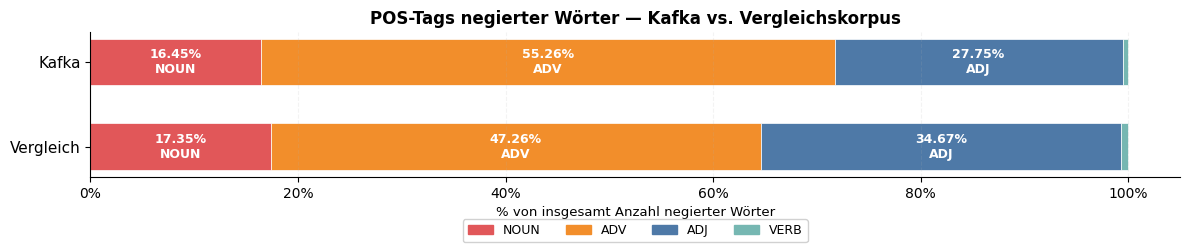

Plot gespeichert: output/pos_tags_negierte_worte.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

farbe_noun = "#e15759"   # rot/coral
farbe_adv  = "#f28e2b"   # orange
farbe_adj  = "#4e79a7"   # blau
farbe_verb = "#76b7b2"   # petrol/teal

# ── POS-Verteilung pro Korpus ────────────────────────────────────
pos_df = df_morpho.merge(
    df_saetze[["werk_id", "satz_id", "korpus"]].drop_duplicates(),
    on=["werk_id", "satz_id"], how="left"
)

pos_counts = pos_df.groupby(["korpus", "pos_tag"]).size().unstack(fill_value=0)
pos_pct = pos_counts.div(pos_counts.sum(axis=1), axis=0) * 100

# Reihenfolge: NOUN, ADV, ADJ, VERB
pos_order = ["NOUN", "ADV", "ADJ", "VERB"]
# Übrige unter "Sonstige" bündeln
other_cols = [c for c in pos_pct.columns if c not in pos_order]
if other_cols:
    pos_pct["Sonstige"] = pos_pct[other_cols].sum(axis=1)
    pos_order_full = pos_order + (["Sonstige"] if pos_pct["Sonstige"].sum() > 0.1 else [])
else:
    pos_order_full = pos_order

farben = {"NOUN": farbe_noun, "ADV": farbe_adv, "ADJ": farbe_adj,
          "VERB": farbe_verb, "Sonstige": "#bbbbbb"}

# Korpus-Reihenfolge: Kafka unten, Vergleich oben (wie im Tableau)
korpus_order = ["vergleich", "kafka"]
korpus_labels = {"kafka": "Kafka", "vergleich": "Vergleich"}

# ── 100 % Stacked Horizontal Bar ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 2.8))

y_pos = np.arange(len(korpus_order))
bar_h = 0.55

for korpus_idx, korpus in enumerate(korpus_order):
    left = 0.0
    for pos in pos_order_full:
        val = pos_pct.loc[korpus, pos] if pos in pos_pct.columns else 0
        bar = ax.barh(korpus_idx, val, left=left, height=bar_h,
                      color=farben.get(pos, "#999999"), edgecolor="white",
                      linewidth=0.5)
        # Beschriftung in der Mitte des Segments
        if val > 4:  # nur beschriften wenn genug Platz
            ax.text(left + val / 2, korpus_idx,
                    f"{val:.2f}%\n{pos}",
                    ha="center", va="center", fontsize=9, fontweight="bold",
                    color="white")
        left += val

ax.set_yticks(y_pos)
ax.set_yticklabels([korpus_labels[k] for k in korpus_order], fontsize=11)
ax.set_xlim(0, 105)
ax.set_xlabel("% von insgesamt Anzahl negierter Wörter", fontsize=9.5)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.15, linestyle="--")

# Legende unterhalb des Charts
handles = [mpatches.Patch(color=farben[p], label=p) for p in pos_order_full]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.25),
          ncol=len(pos_order_full), fontsize=9, framealpha=0.9)

ax.set_title("POS-Tags negierter Wörter — Kafka vs. Vergleichskorpus",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(module_path, "output", "pos_tags_negierte_worte.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: output/pos_tags_negierte_worte.png")

Gematchte Werke: 41 / 41
Zeitraum: 1905 – 1924

 Erstellung  n_werke  n_tokens  morpho_per_1000  dn_per_100_saetze  pct_saetze_mit_neg
       1905        3     17877         6.544722           1.164875            9.498208
       1908        1      8399         3.333730           1.969365            5.908096
       1912        4     39145         6.335420           2.194997           11.281266
       1914        3     94371         5.202870           1.508485            9.260423
       1915        4     80751         6.513851           1.851852           10.973937
       1917       15     19514         7.481808           1.896813            9.939302
       1920        2      1535         5.211726          11.538462           13.461538
       1922        6     96354         6.912012           3.109029           12.095400
       1923        1      2692        10.401189          11.764706           20.588235
       1924        2     18874         7.894458           4.911323           16.64

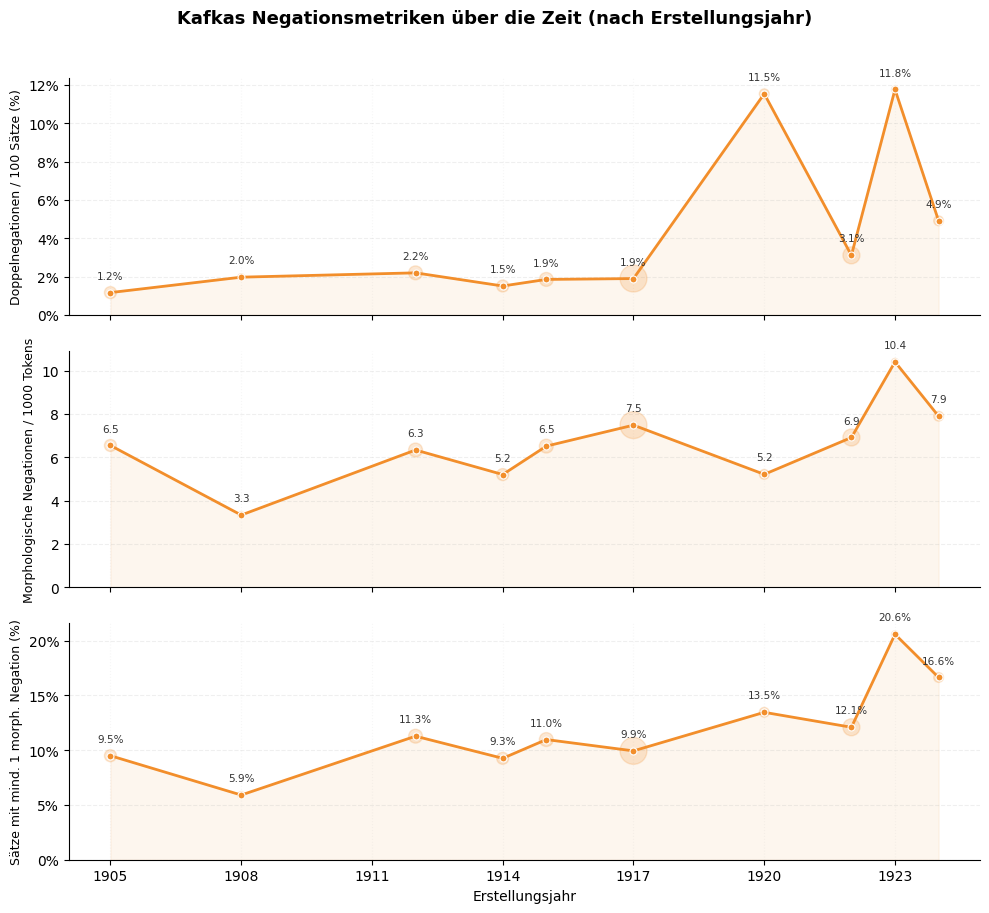

Plot gespeichert: output/metriken_zeitreihe.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 1. Entstehungsjahre laden & mergen ───────────────────────────
titel_path = os.path.join(module_path, "output",
    "titel_mit_entstehungs_und_veröffentlichungsjahr - Tabelle mit Kafka-Titeln und Daten.csv")
df_titel = pd.read_csv(titel_path, encoding="utf-8")

# werk_id bereinigen (abgeschnittene Namen z.B. "hochzeitsvorbereitungen_auf_dem_lan..")
df_titel["werkid"] = df_titel["werkid"].str.replace(r"\.+$", "", regex=True)

# Merge: werk_stats (nur Kafka) × Erstellungsjahr
kafka_zeit = werk_stats[werk_stats["korpus"] == "kafka"].copy()

# Flexibler Merge: exakt oder Präfix-Match
def match_werkid(wid, titel_ids):
    """Versuche exakten Match, sonst Präfix-Match."""
    if wid in titel_ids:
        return wid
    for tid in titel_ids:
        if wid.startswith(tid) or tid.startswith(wid):
            return tid
    return None

titel_ids = df_titel["werkid"].tolist()
kafka_zeit["werkid_match"] = kafka_zeit["werk_id"].apply(lambda w: match_werkid(w, titel_ids))

# Merge
kafka_zeit = kafka_zeit.merge(
    df_titel[["werkid", "Erstellung"]].rename(columns={"werkid": "werkid_match"}),
    on="werkid_match", how="left"
)

# Nicht gematchte anzeigen
nicht_gematcht = kafka_zeit[kafka_zeit["Erstellung"].isna()]["werk_id"].tolist()
if nicht_gematcht:
    print(f"⚠ Nicht gematcht ({len(nicht_gematcht)}): {nicht_gematcht}")

kafka_zeit = kafka_zeit.dropna(subset=["Erstellung"])
kafka_zeit["Erstellung"] = kafka_zeit["Erstellung"].astype(int)

print(f"Gematchte Werke: {len(kafka_zeit)} / {len(werk_stats[werk_stats['korpus'] == 'kafka'])}")
print(f"Zeitraum: {kafka_zeit['Erstellung'].min()} – {kafka_zeit['Erstellung'].max()}")

# ── 2. Pro Jahr aggregieren ──────────────────────────────────────
jahr_agg = kafka_zeit.groupby("Erstellung").agg(
    n_werke=("werk_id", "count"),
    n_saetze=("n_saetze", "sum"),
    n_tokens=("n_tokens", "sum"),
    n_morpho_neg=("n_morpho_neg", "sum"),
    n_doppelneg=("n_doppelneg", "sum"),
    n_saetze_mit_neg=("n_saetze_mit_neg", "sum"),
).reset_index()

# Raten pro Jahr
jahr_agg["morpho_per_1000"]    = jahr_agg["n_morpho_neg"] / jahr_agg["n_tokens"] * 1000
jahr_agg["dn_per_100_saetze"]  = jahr_agg["n_doppelneg"]  / jahr_agg["n_saetze"] * 100
jahr_agg["pct_saetze_mit_neg"] = jahr_agg["n_saetze_mit_neg"] / jahr_agg["n_saetze"] * 100

print()
print(jahr_agg[["Erstellung", "n_werke", "n_tokens", "morpho_per_1000",
                 "dn_per_100_saetze", "pct_saetze_mit_neg"]].to_string(index=False))

# ── 3. Zeitreihen-Plot (3 Subplots) ─────────────────────────────
farbe_kafka = "#f28e2b"

metriken_zeit = [
    ("Doppelnegationen / 100 Sätze (%)",       "dn_per_100_saetze",  "%"),
    ("Morphologische Negationen / 1000 Tokens", "morpho_per_1000",   ""),
    ("Sätze mit mind. 1 morph. Negation (%)",   "pct_saetze_mit_neg", "%"),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for ax, (label, col_name, fmt) in zip(axes, metriken_zeit):
    x = jahr_agg["Erstellung"]
    y = jahr_agg[col_name]

    ax.plot(x, y, color=farbe_kafka, linewidth=2, marker="o", markersize=5,
            markerfacecolor=farbe_kafka, markeredgecolor="white", markeredgewidth=0.8,
            zorder=3)

    # Fläche unter Kurve leicht füllen
    ax.fill_between(x, y, alpha=0.08, color=farbe_kafka)

    # Werke-Anzahl als Blasengröße
    sizes = jahr_agg["n_werke"] * 25
    ax.scatter(x, y, s=sizes, color=farbe_kafka, alpha=0.2, zorder=2)

    # Werte annotieren
    for xi, yi, n in zip(x, y, jahr_agg["n_werke"]):
        if fmt == "%":
            txt = f"{yi:.1f}%"
        else:
            txt = f"{yi:.1f}"
        ax.annotate(txt, (xi, yi), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=7.5, color="#333333")

    ax.set_ylabel(label, fontsize=9)
    if fmt == "%":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.grid(axis="x", alpha=0.1, linestyle=":")

# X-Achse nur unten
axes[-1].set_xlabel("Erstellungsjahr", fontsize=10)
axes[-1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle("Kafkas Negationsmetriken über die Zeit (nach Erstellungsjahr)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(module_path, "output", "metriken_zeitreihe.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: output/metriken_zeitreihe.png")